In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [20]:
nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
data=pd.read_csv('IMDB Dataset.csv')
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [23]:
data['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


## Preprocessing

In [24]:
data['sentiment']=data['sentiment'].map({'positive':0,'negative':1})
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,0
1,A wonderful little production. <br /><br />The...,0
2,I thought this was a wonderful way to spend ti...,0
3,Basically there's a family where a little boy ...,1
4,"Petter Mattei's ""Love in the Time of Money"" is...",0


In [25]:
stop_words=set(stopwords.words('english'))
def clean_text (text):

  text = text.lower()
  text = re.sub(r'<br\s*/?>',' ',text)
  text = re.sub(r'[^a-zA-Z\s]',' ',text)

  tokens = word_tokenize(text)
  tokens = [w for w in tokens if w not in stop_words]

  return ' '.join(tokens)

In [26]:
nltk.download('punkt_tab')
data['review']=data['review'].apply(clean_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [27]:
data.head()

,review,sentiment
0,one reviewers mentioned watching oz episode ho...,0
1,wonderful little production br br filming tech...,0
2,thought wonderful way spend time hot summer we...,0
3,basically family little boy jake thinks zombie...,1
4,petter mattei love time money visually stunnin...,0


In [28]:
X=data['review']
y=data['sentiment']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

vectorizer=TfidfVectorizer()
X_train_tfidf=vectorizer.fit_transform(X_train)
X_test_tfidf=vectorizer.transform(X_test)


## Train models

In [29]:
log_reg=LogisticRegression()
log_reg.fit(X_train_tfidf,y_train)
y_pred_log_reg=log_reg.predict(X_test_tfidf)

print("=== Logistic Regression Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg))

=== Logistic Regression Performance ===
Accuracy: 0.8981

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.91      0.90      5039
           1       0.91      0.88      0.90      4961

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



## Bonus

In [30]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

acc_log = accuracy_score(y_test, y_pred_log_reg)
acc_nb = accuracy_score(y_test, y_pred_nb)

print("=== Model Comparison ===")
print(f"Logistic Regression Accuracy: {acc_log * 100:.2f}%")
print(f"Naive Bayes Accuracy:          {acc_nb * 100:.2f}%")

=== Model Comparison ===
Logistic Regression Accuracy: 89.81%
Naive Bayes Accuracy:          86.69%


/tmp/ipykernel_382/3799078893.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[x[1] for x in top_pos], y=[x[0] for x in top_pos], ax=axes[0], palette="Greens_r")
/tmp/ipykernel_382/3799078893.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[x[1] for x in top_neg], y=[x[0] for x in top_neg], ax=axes[1], palette="Reds_r")


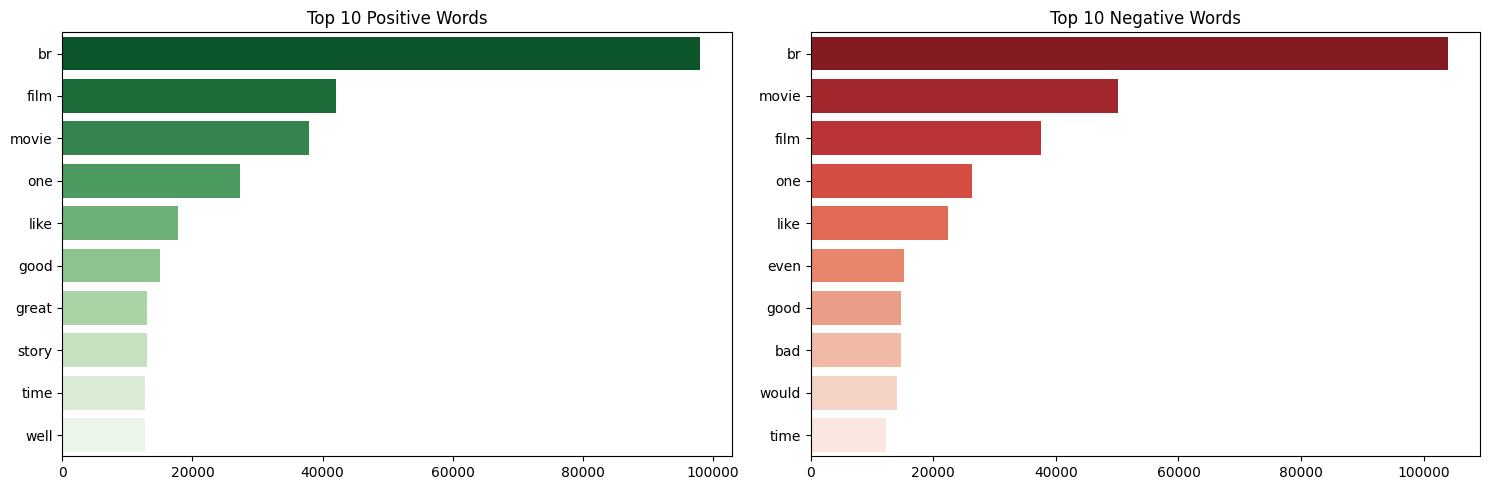

In [31]:
from collections import Counter

pos_reviews = data[data['sentiment'] == 0.0]['review']
neg_reviews = data[data['sentiment'] == 1.0]['review']
pos_words = " ".join(pos_reviews).split()
neg_words = " ".join(neg_reviews).split()

top_pos = Counter(pos_words).most_common(10)
top_neg = Counter(neg_words).most_common(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=[x[1] for x in top_pos], y=[x[0] for x in top_pos], ax=axes[0], palette="Greens_r")
axes[0].set_title("Top 10 Positive Words")

sns.barplot(x=[x[1] for x in top_neg], y=[x[0] for x in top_neg], ax=axes[1], palette="Reds_r")
axes[1].set_title("Top 10 Negative Words")

plt.tight_layout()
plt.show()